# Hermite Polynomial Forecast (HiCache)

This is a focused successor to `Hermite_Lookahead_Learning.ipynb`. It adopts only the **Hermite polynomial velocity-forecast method** described by `Archerkattri/hunyuan2-plus`; it intentionally removes the earlier online ridge predictor and symbolic polynomial cache.

At a full/compute step, HiCache stores an expensive model output (the CFG-combined velocity) and updates backward finite-difference derivatives. At skipped steps it forecasts the velocity and avoids the model call:

$$\widehat F_{t+k}=F_t+\sum_{i=1}^{m}\frac{\Delta^iF_t}{i!}\,\widetilde H_i(k),$$

$$\widetilde H_n(x)=\sigma^nH_n(\sigma x),\qquad 0<\sigma<1.$$

The basis uses physicists' Hermite polynomials and the corrected **forward** distance $x=+k$. With fewer than two anchors, the official implementation safely reuses the last velocity.

Sources: [hunyuan2-plus README](https://github.com/Archerkattri/hunyuan2-plus), [`hicache.py` facade](https://github.com/Archerkattri/hunyuan2-plus/blob/main/hy3dgen/shapegen/hicache.py), and [hicache-plus-plus](https://github.com/Archerkattri/hicache-plus-plus).

## Dependencies and resources

This notebook's CPU demonstration requires only:

- `hicache-pp>=1.2.1` (the repository's corrected-sign shared core)
- `torch`
- `numpy` and `matplotlib` for evaluation and plots

Run the next cell if the environment does not already contain them. A real Hunyuan3D-2 mini run additionally needs the repository's full `requirements.txt`, a compatible PyTorch/CUDA environment, the repository source, and Tencent's `tencent/Hunyuan3D-2mini` weights. Those large model resources are not needed—and are not downloaded—for this method-focused notebook.

In [1]:
# Uncomment when setting up a fresh kernel, then restart the kernel.
# %pip install "hicache-pp>=1.2.1" torch numpy matplotlib

In [2]:
from __future__ import annotations

from dataclasses import dataclass
from importlib.metadata import version
from time import perf_counter
import math

import matplotlib.pyplot as plt
import numpy as np
import torch

from hicache_pp.hermite import (
    hicache_decide,
    hicache_forecast,
    hicache_init,
    hicache_reset,
    hicache_telemetry,
    hicache_update_derivatives,
    physicists_hermite,
    scaled_hermite,
)

torch.set_default_dtype(torch.float64)
print("hicache-pp", version("hicache-pp"))
print("torch", torch.__version__, "| device: CPU")

hicache-pp 1.3.0
torch 2.10.0 | device: CPU


## 1. Inspect the contracted Hermite basis

The dual scaling contracts both polynomial amplitude and argument. It is the defining difference from a monomial/TaylorSeer basis. The first-order term is

$$\widetilde H_1(k)=2\sigma^2k.$$

Consequently, $\sigma=\sqrt{1/2}$ makes the first-order basis equal to $k$, which is useful for the exact linear-series sign test below.

k: [0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
H_tilde_0(k), sigma=0.5: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
H_tilde_1(k), sigma=0.5: [0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0]
H_tilde_2(k), sigma=0.5: [-0.5, -0.25, 0.5, 1.75, 3.5, 5.75, 8.5]
H_tilde_3(k), sigma=0.5: [-0.0, -0.625, -0.5, 1.125, 5.0, 11.875, 22.5]
H_tilde_4(k), sigma=0.5: [0.75, 0.0625, -1.25, -0.9375, 4.75, 21.0625, 54.75]


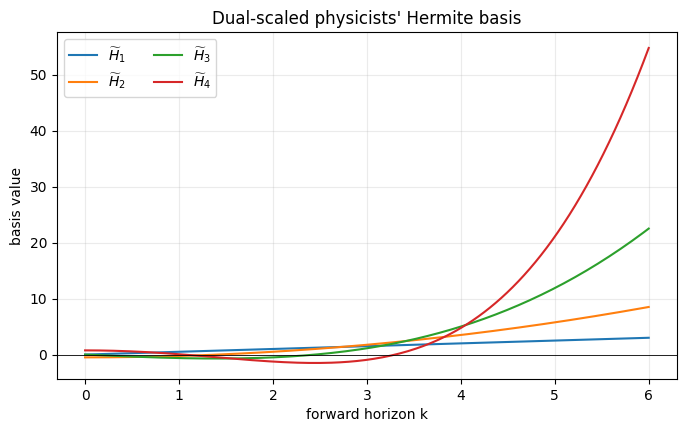

In [3]:
ks = torch.arange(0, 7, dtype=torch.float64)
sigma = 0.5

print("k:", ks.tolist())
for order in range(5):
    values = scaled_hermite(order, ks, sigma)
    print(f"H_tilde_{order}(k), sigma={sigma}:", [round(v, 6) for v in values.tolist()])

fig, ax = plt.subplots(figsize=(8, 4.5))
grid = torch.linspace(0, 6, 200)
for order in range(1, 5):
    ax.plot(grid.numpy(), scaled_hermite(order, grid, sigma).numpy(), label=fr"$\widetilde H_{order}$")
ax.axhline(0, color="black", lw=0.6)
ax.set(title="Dual-scaled physicists' Hermite basis", xlabel="forward horizon k", ylabel="basis value")
ax.legend(ncols=2); ax.grid(alpha=0.25)
plt.show()

## 2. A method-only sampler harness

`HermiteForecastRunner` mirrors the repository's denoise-loop contract. On a `full` decision it calls the supplied velocity function and updates derivatives. On a `forecast` decision it calls the official `hicache_forecast` and skips the expensive function. The state advances exactly once per sampling step.

In [4]:
@dataclass(frozen=True)
class ForecastConfig:
    num_steps: int
    interval: int = 4
    max_order: int = 1
    first_enhance: int = 2
    end_enhance: int | None = None
    sigma: float = 0.5


class HermiteForecastRunner:
    def __init__(self, config: ForecastConfig):
        self.config = config
        self.state = hicache_init(**vars(config), backend="hermite")

    def reset(self):
        hicache_reset(self.state)
        return self

    def run(self, velocity_fn):
        outputs, decisions = [], []
        started = perf_counter()
        for step in range(self.config.num_steps):
            # step is maintained explicitly, as in the repository integration.
            self.state["step"] = step
            decision = hicache_decide(self.state)
            if decision == "full":
                velocity = velocity_fn(step).detach()
                hicache_update_derivatives(self.state, velocity)
            else:
                velocity = hicache_forecast(self.state)
            outputs.append(velocity.clone())
            decisions.append(decision)
            self.state["step"] += 1
        return {
            "values": torch.stack(outputs),
            "decisions": decisions,
            "telemetry": hicache_telemetry(self.state),
            "elapsed_s": perf_counter() - started,
        }

## 3. Forecast a vector-valued velocity trajectory

The synthetic function stands in for a costly DiT forward pass and returns a small vector so the notebook remains CPU-only. HiCache is tensor-shape agnostic: the same arithmetic applies to large latent velocity tensors. We compare every served value with the exact full-step trajectory.

In [5]:
def velocity_truth(step: int) -> torch.Tensor:
    s = torch.tensor(float(step))
    # Smooth but not exactly polynomial: a useful local-forecast exercise.
    return torch.stack((
        torch.sin(0.22*s) + 0.015*s,
        torch.cos(0.13*s) - 0.01*s,
        torch.exp(-0.045*s),
        0.002*s**2 - 0.04*s + 0.3,
    ))

num_steps = 32
config = ForecastConfig(num_steps=num_steps, interval=4, max_order=1,
                        first_enhance=2, sigma=0.5)
runner = HermiteForecastRunner(config)
result = runner.run(velocity_truth)
truth = torch.stack([velocity_truth(i) for i in range(num_steps)])
error = torch.linalg.vector_norm(result["values"] - truth, dim=1)

full_calls = result["decisions"].count("full")
forecast_calls = result["decisions"].count("forecast")
print("decisions:", " ".join("F" if d == "full" else "h" for d in result["decisions"]))
print(f"full calls={full_calls}, forecasts={forecast_calls}, avoided fraction={forecast_calls/num_steps:.1%}")
print(f"mean L2 error={error.mean():.6f}, max L2 error={error.max():.6f}")
print("telemetry:", result["telemetry"])

decisions: F F h h h F h h h F h h h F h h h F h h h F h h h F h h h F h h
full calls=9, forecasts=23, avoided fraction=71.9%
mean L2 error=0.164068, max L2 error=0.527181
telemetry: {'decisions': {'full': 9, 'forecast': 23}, 'method_counts': {'hermite': 23, 'dmd': 0, 'reuse': 0}, 'fallbacks': {}}


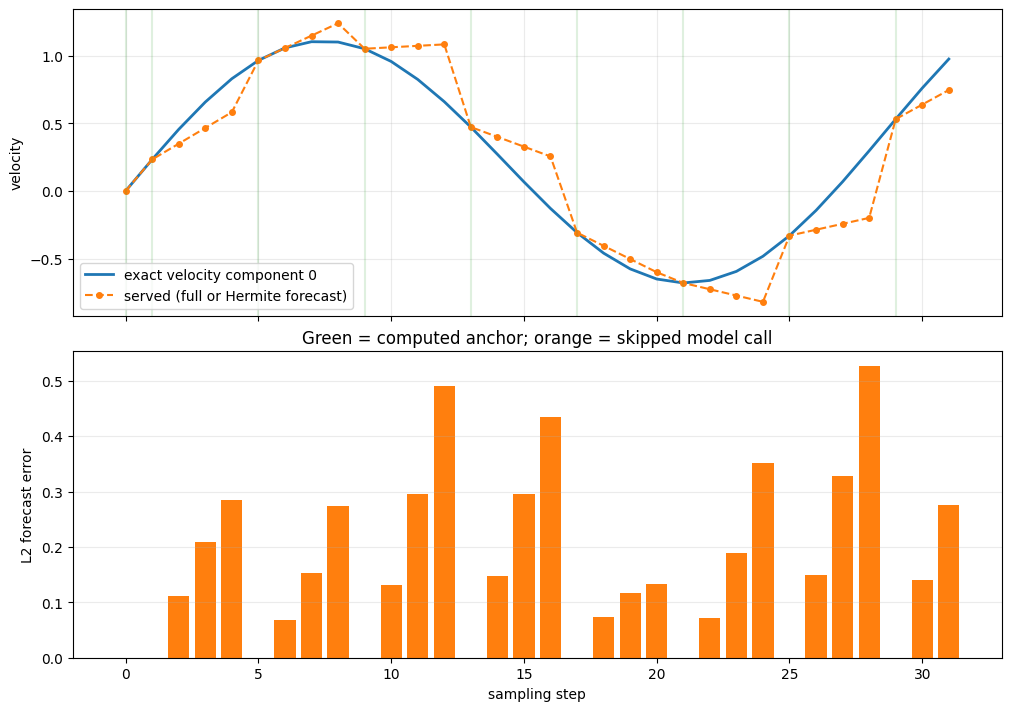

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, constrained_layout=True)
steps = np.arange(num_steps)
axes[0].plot(steps, truth[:, 0], label="exact velocity component 0", lw=2)
axes[0].plot(steps, result["values"][:, 0], "o--", ms=4, label="served (full or Hermite forecast)")
for i, decision in enumerate(result["decisions"]):
    if decision == "full": axes[0].axvline(i, color="tab:green", alpha=0.15)
axes[0].set_ylabel("velocity"); axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].bar(steps, error.numpy(), color=["tab:green" if d == "full" else "tab:orange" for d in result["decisions"]])
axes[1].set(xlabel="sampling step", ylabel="L2 forecast error", title="Green = computed anchor; orange = skipped model call")
axes[1].grid(axis="y", alpha=0.25)
plt.show()

## 4. Show finite-difference learning at anchors

This is training-free online adaptation. At each compute step, the state derives new backward differences from current and previous anchors; it does not optimize model weights. The distance is taken from actual activated-step indices, so warm-up spacing is handled correctly.

In [7]:
trace_state = hicache_init(num_steps=12, interval=4, max_order=3,
                           first_enhance=2, sigma=0.5)
for step in range(12):
    trace_state["step"] = step
    decision = hicache_decide(trace_state)
    if decision == "full":
        hicache_update_derivatives(trace_state, velocity_truth(step))
        norms = {order: round(float(value.norm()), 6)
                 for order, value in trace_state["derivatives"].items()}
        print(f"step {step:2d} FULL     derivative norms {norms}")
    else:
        value = hicache_forecast(trace_state)
        horizon = step - trace_state["activated_steps"][-1]
        print(f"step {step:2d} FORECAST k={horizon}  norm={float(value.norm()):.6f}")
    trace_state["step"] += 1

step  0 FULL     derivative norms {0: 1.445683}
step  1 FULL     derivative norms {0: 1.414367, 1: 0.241073}
step  2 FORECAST k=1  norm=1.413945
step  3 FORECAST k=2  norm=1.423763
step  4 FORECAST k=3  norm=1.443615
step  5 FULL     derivative norms {0: 1.466399, 1: 0.198439, 2: 0.016307}
step  6 FORECAST k=1  norm=1.504152
step  7 FORECAST k=2  norm=1.540988
step  8 FORECAST k=3  norm=1.579495
step  9 FULL     derivative norms {0: 1.285682, 1: 0.118822, 2: 0.042726, 3: 0.007034}
step 10 FORECAST k=1  norm=1.278814
step 11 FORECAST k=2  norm=1.256320


## 5. Parameter sweep: speed proxy versus drift

The useful trade-off is avoided model calls versus deviation from the all-full baseline. `interval` controls the skip horizon; `max_order` controls how many available differences enter the forecast; `sigma` contracts the Hermite basis. No learned ridge/DMD/ML alternative is used here.

In [8]:
rows = []
for interval in (2, 3, 4, 5, 6):
    for max_order in (1, 2, 3):
        for sigma in (0.4, 0.5, math.sqrt(0.5)):
            cfg = ForecastConfig(num_steps=48, interval=interval, max_order=max_order,
                                 first_enhance=2, sigma=sigma)
            out = HermiteForecastRunner(cfg).run(velocity_truth)
            target = torch.stack([velocity_truth(i) for i in range(cfg.num_steps)])
            err = torch.linalg.vector_norm(out["values"] - target, dim=1)
            skipped = out["decisions"].count("forecast")
            rows.append({"interval": interval, "order": max_order, "sigma": sigma,
                         "avoided": skipped/cfg.num_steps,
                         "mean_error": float(err.mean()), "max_error": float(err.max())})

best = sorted(rows, key=lambda r: r["mean_error"])
print("Lowest mean-error configurations:")
for row in best[:10]:
    print({k: (round(v, 6) if isinstance(v, float) else v) for k, v in row.items()})

Lowest mean-error configurations:
{'interval': 2, 'order': 1, 'sigma': 0.707107, 'avoided': 0.479167, 'mean_error': 0.023372, 'max_error': 0.074729}
{'interval': 2, 'order': 2, 'sigma': 0.707107, 'avoided': 0.479167, 'mean_error': 0.023372, 'max_error': 0.074729}
{'interval': 2, 'order': 3, 'sigma': 0.707107, 'avoided': 0.479167, 'mean_error': 0.023918, 'max_error': 0.077135}
{'interval': 2, 'order': 1, 'sigma': 0.5, 'avoided': 0.479167, 'mean_error': 0.049349, 'max_error': 0.138768}
{'interval': 2, 'order': 3, 'sigma': 0.5, 'avoided': 0.479167, 'mean_error': 0.050434, 'max_error': 0.142784}
{'interval': 2, 'order': 2, 'sigma': 0.5, 'avoided': 0.479167, 'mean_error': 0.050568, 'max_error': 0.143322}
{'interval': 3, 'order': 3, 'sigma': 0.707107, 'avoided': 0.645833, 'mean_error': 0.059441, 'max_error': 0.183092}
{'interval': 3, 'order': 2, 'sigma': 0.707107, 'avoided': 0.645833, 'mean_error': 0.059459, 'max_error': 0.185676}
{'interval': 2, 'order': 1, 'sigma': 0.4, 'avoided': 0.479167

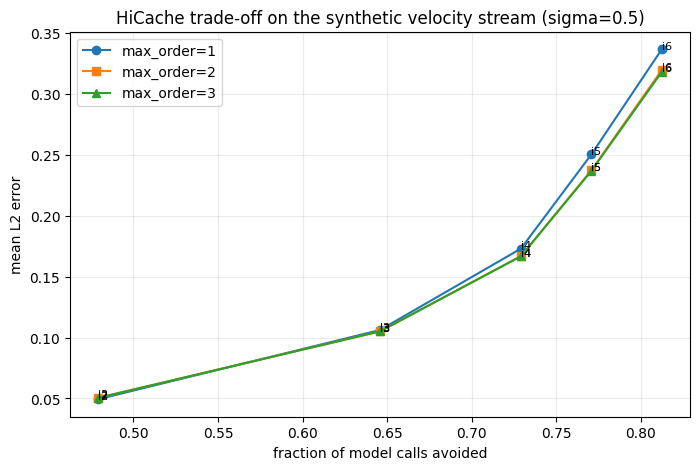

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
for order, marker in ((1, "o"), (2, "s"), (3, "^")):
    selected = [r for r in rows if r["order"] == order and abs(r["sigma"] - 0.5) < 1e-12]
    ax.plot([r["avoided"] for r in selected], [r["mean_error"] for r in selected],
            marker=marker, label=f"max_order={order}")
    for r in selected:
        ax.annotate(f"i{r['interval']}", (r["avoided"], r["mean_error"]), fontsize=8)
ax.set(xlabel="fraction of model calls avoided", ylabel="mean L2 error",
       title="HiCache trade-off on the synthetic velocity stream (sigma=0.5)")
ax.grid(alpha=0.25); ax.legend()
plt.show()

## 6. Correctness and regression tests

The forward-sign test is especially important: at $\sigma=\sqrt{1/2}$, first-order forecasting must exactly continue a linear series. Evaluating at $-k$ would move backward and fail this test.

In [10]:
checks = {}
xs = torch.tensor([-1.5, 0.0, 0.7, 2.0])
checks["H0"] = torch.allclose(physicists_hermite(0, xs), torch.ones_like(xs))
checks["H1"] = torch.allclose(physicists_hermite(1, xs), 2*xs)
checks["H2"] = torch.allclose(physicists_hermite(2, xs), 4*xs**2 - 2)
checks["scaled definition"] = torch.allclose(
    scaled_hermite(3, xs, 0.5), 0.5**3 * physicists_hermite(3, 0.5*xs))

# One anchor: the zero-information forecast is exact reuse.
reuse = hicache_init(num_steps=5, interval=4, max_order=2, first_enhance=0, sigma=0.5)
reuse["step"] = 0; reuse["activated_steps"].append(0)
anchor = torch.tensor([2.0, -1.0])
hicache_update_derivatives(reuse, anchor)
reuse["step"] = 1
checks["one-anchor reuse"] = torch.equal(hicache_forecast(reuse), anchor)

# Two anchors from F_s=a+b*s: corrected +k convention is exact at sigma=sqrt(1/2).
a = torch.tensor([1.0, -2.0]); b = torch.tensor([0.3, -0.15]); spacing = 4
linear = hicache_init(num_steps=10, interval=spacing, max_order=1,
                      first_enhance=0, sigma=math.sqrt(0.5))
for step in (0, spacing):
    linear["step"] = step; linear["activated_steps"].append(step)
    hicache_update_derivatives(linear, a + b*step)
linear["step"] = spacing + 2
checks["corrected +k linear forecast"] = torch.allclose(
    hicache_forecast(linear), a + b*(spacing+2), atol=1e-12)

# Constant feature streams remain exact at every available order.
constant = hicache_init(num_steps=10, interval=4, max_order=3,
                        first_enhance=0, sigma=0.5)
for step in (0, 4):
    constant["step"] = step; constant["activated_steps"].append(step)
    hicache_update_derivatives(constant, anchor)
constant["step"] = 7
checks["constant stream"] = torch.equal(hicache_forecast(constant), anchor)

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'}  {name}")
assert all(bool(v) for v in checks.values())
print(f"All {len(checks)} checks passed.")

PASS  H0
PASS  H1
PASS  H2
PASS  scaled definition
PASS  one-anchor reuse
PASS  corrected +k linear forecast
PASS  constant stream
All 7 checks passed.


## 7. Optional Hunyuan3D-2 mini integration

This final cell is documentation and is not executed. It shows the repository-native entry point. Running it requires cloning `Archerkattri/hunyuan2-plus`, installing its full requirements, accepting the upstream model terms, downloading the Hunyuan3D-2 mini weights, and using suitable hardware. The notebook's completed CPU sections already exercise the same official forecast core.

In [11]:
# NOT RUN: large model/GPU integration example from the repository contract.
# from PIL import Image
# from hy3dgen.shapegen import Hunyuan3DDiTFlowMatchingPipeline
#
# pipe = Hunyuan3DDiTFlowMatchingPipeline.from_pretrained(
#     "tencent/Hunyuan3D-2mini", subfolder="hunyuan3d-dit-v2-mini"
# )
# pipe.enable_hicache(
#     interval=4,
#     max_order=1,
#     first_enhance=2,
#     end_enhance=None,
#     sigma=0.5,
# )
# mesh = pipe(image=Image.open("assets/demo.png").convert("RGBA"))[0]
# mesh.export("demo_hicache.glb")
print("Optional integration cell intentionally not run: no model weights are required for this notebook.")

Optional integration cell intentionally not run: no model weights are required for this notebook.


## Interpretation

- HiCache forecasting is **training-free**: “learning” here means updating finite differences from new full-step anchors, not fitting neural-network weights.
- The method forecasts a model's **feature/velocity trajectory**; it does not forecast the sequence of symbolic Hermite polynomials.
- `interval=4`, `max_order=1`, `first_enhance=2`, and `sigma=0.5` reproduce the repository README's recommended baseline configuration.
- Larger intervals avoid more model calls but extrapolate farther. The repository warns that the polynomial basis can degrade as the skip horizon grows.
- A real speedup depends on the skipped DiT being much more expensive than the small cache arithmetic; this CPU notebook reports avoided-call fraction as the hardware-independent speed proxy.